In [6]:
import numpy as np

# Gibbs sampling for a bivariate normal distribution
def gibbs_sampling(row = 0.5, num_samples = 1000, x = 0, y = 0):
    samples = np.zeros((num_samples, 2))
    x, y = x, y  # Initial values

    for i in range(num_samples):
        x = np.random.normal(row * y, (1 - row**2))
        y = np.random.normal(row * x, (1 - row**2))
        samples[i] = [x, y]

    return samples

In [33]:
# plot the samples
import matplotlib.pyplot as plt
def plot_samples(samples, title):
    plt.scatter(samples[:, 0], samples[:, 1], s=2)
    # plt.figure(figsize=(10, 10))
    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.axis('equal')
    plt.grid()
    plt.show()

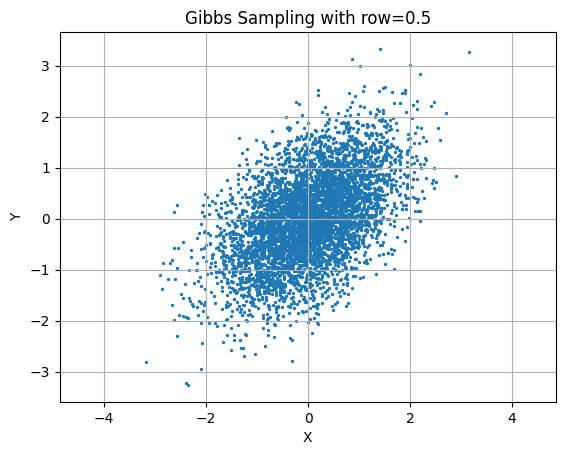

In [56]:
num_samples = 5000
row = 0.5
one_long_run_samples = gibbs_sampling(row, num_samples)
# print(one_long_run_samples)
plot_samples(one_long_run_samples, f'Gibbs Sampling with row={row}')

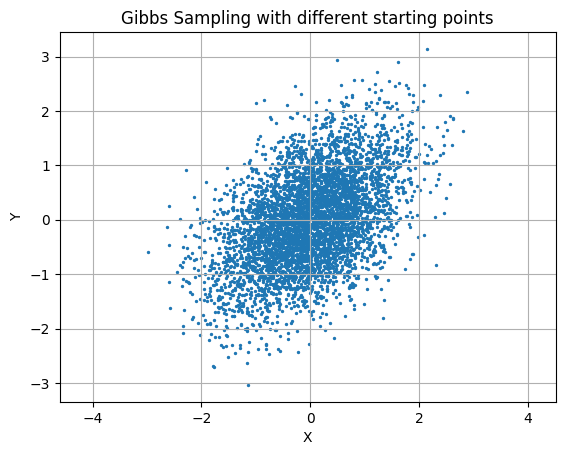

In [60]:
# Generate 5 different sets of sample with different starting points for x and y store all in single list and plot all the samples.
starting_points = [(0, 0), (1, 1), (-1, -1), (1, -1), (-1, 1)]
num_samples = 1000
total_samples = []
all_samples_multiple_chain = []
for x_start, y_start in starting_points:
    samples = gibbs_sampling(row, num_samples, x_start, y_start)
    total_samples.append(samples)
    all_samples_multiple_chain = np.vstack(total_samples)

# print(total_samples)
plot_samples(all_samples_multiple_chain, 'Gibbs Sampling with different starting points')

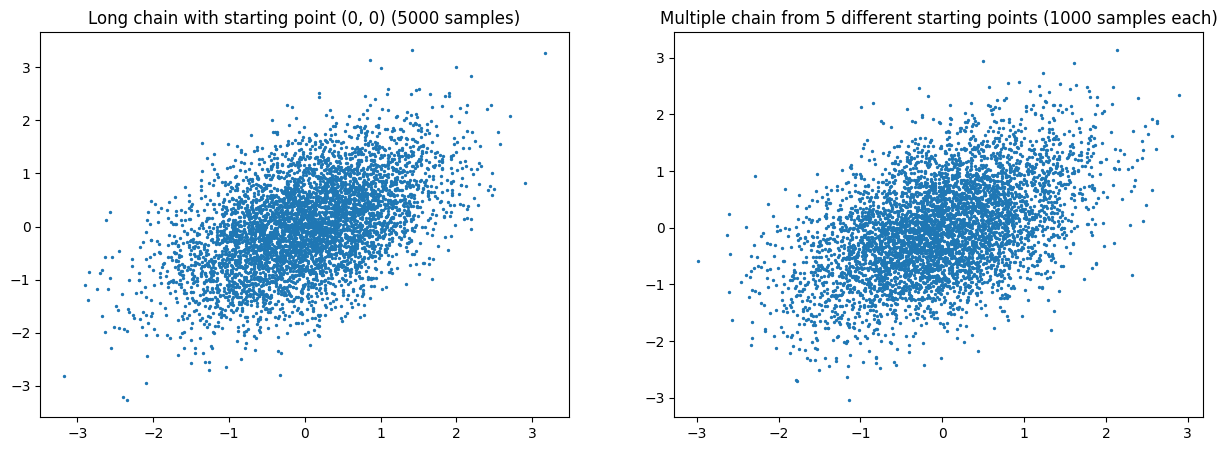

In [61]:
#  Use subplot to plots multiple graphs in a single figure. Plot the samples from the first run and the samples from all the runs in two different subplots.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(one_long_run_samples[:, 0], one_long_run_samples[:, 1], s=2)
axes[0].set_title('Long chain with starting point (0, 0) (5000 samples)')
axes[1].scatter(all_samples_multiple_chain[:, 0], all_samples_multiple_chain[:, 1], s=2)
axes[1].set_title('Multiple chain from 5 different starting points (1000 samples each)')
plt.show()

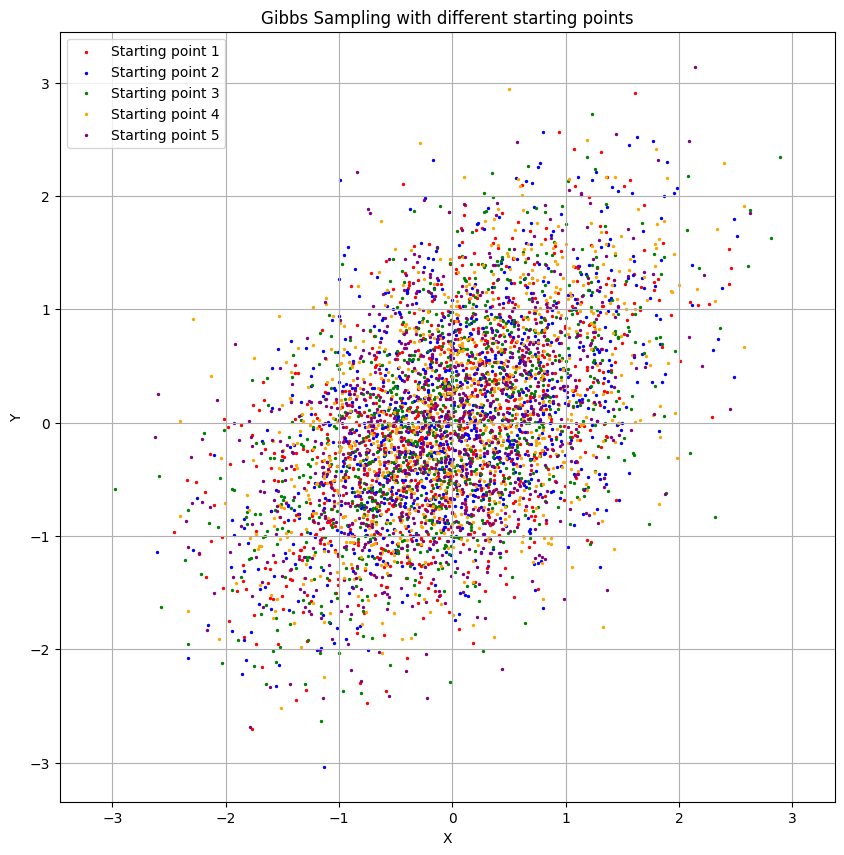

In [63]:
#  Plot both the samples in the same plot with different colors for each set of samples.
colors = ['red', 'blue', 'green', 'orange', 'purple']
plt.figure(figsize=(10, 10))
for i, samples in enumerate(total_samples):
    plt.scatter(samples[:, 0], samples[:, 1], s=2, color=colors[i], label=f'Starting point {i+1}')
plt.title('Gibbs Sampling with different starting points')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.grid()
plt.legend()
plt.show()

In [64]:
# Display mean and variance for single chain and multiple chain samples.
print("Single chain samples mean:", np.mean(one_long_run_samples, axis=0))
print("Single chain samples variance:", np.var(one_long_run_samples, axis=0))
print("-" * 20)
print("Multiple chain samples mean:", np.mean(all_samples_multiple_chain, axis=0))
print("Multiple chain samples variance:", np.var(all_samples_multiple_chain, axis=0))

Single chain samples mean: [0.0050387  0.00794451]
Single chain samples variance: [0.74597583 0.74058105]
--------------------
Multiple chain samples mean: [-0.03256878 -0.0190621 ]
Multiple chain samples variance: [0.71922053 0.72091011]
